# CNN

## Import Images

In [1]:
import numpy as np
from pathlib import Path
import gzip

%load_ext autoreload
%autoreload 2

# Read info from compressed binary format
BASE_DIR = Path.cwd().parent

# Labels
label_path = BASE_DIR / "MNIST" / 'train-labels-idx1-ubyte.gz'
with gzip.open(label_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_labels = int.from_bytes(f.read(4)) # Number of labels
    labels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of items according to file: {n_labels}")
print(f"actual number of items: {len(labels)}")

# Images
img_path = BASE_DIR / "MNIST" / 'train-images-idx3-ubyte.gz'
with gzip.open(img_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_images = int.from_bytes(f.read(4)) # Number of images
    n_rows = int.from_bytes(f.read(4))
    n_cols = int.from_bytes(f.read(4))
    pixels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of images according to file: {n_labels}")
print(f"n_rows: {n_rows}")
print(f"n_cols: {n_cols}")
print(f"actual number of images: {len(pixels) // (n_rows * n_cols)}")

imgs = pixels.reshape(n_images, n_rows, n_cols)
print(f"number of reshapes images: {len(imgs)}")

number of items according to file: 60000
actual number of items: 60000
number of images according to file: 60000
n_rows: 28
n_cols: 28
actual number of images: 60000
number of reshapes images: 60000


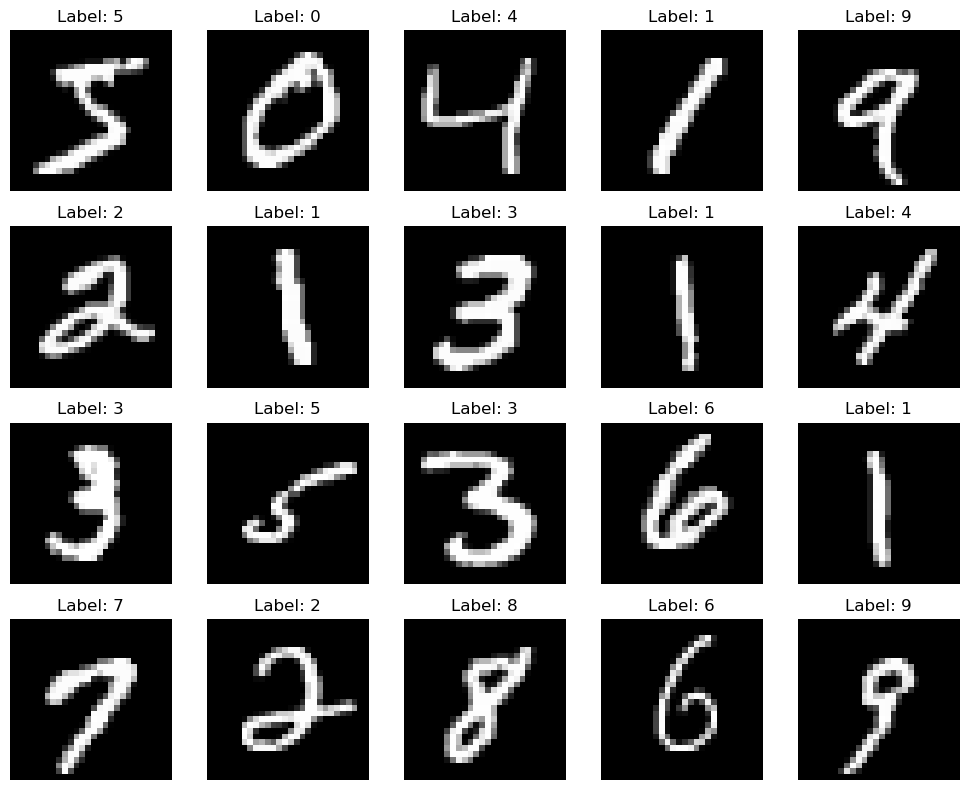

In [2]:
import matplotlib.pyplot as plt

def show_image_grid(imgs, labels, preds=None, ids=range(20), cols=5):
    rows = int(np.ceil(len(ids) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).reshape(-1)

    for ax, id in zip(axes, ids):
        ax.imshow(imgs[id], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Label: {labels[id]}")
        if preds is not None:
            ax.set_title(f"Label: {labels[id]}\nPred: {preds[0][id]}\nConfidence: {preds[1][id]:.3f}")

    for ax in axes[len(ids):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_image_grid(imgs, labels, ids=range(20), cols=5)

In [3]:
# TODO:
# Implement eval / train mode for model - dont want to store vars during eval
# Implement float32 instead of float64

In [5]:
num_classes = 10

cutoff = -1
cutoff = 10000
data_imgs = imgs[:cutoff]
data_labels = labels[:cutoff]
n = len(data_imgs)

shuffled_indices = np.random.permutation(n)
shuffled_imgs = data_imgs[shuffled_indices]
shuffled_labels = data_labels[shuffled_indices]

train_frac = 0.8
train_size = int(n * train_frac)
val_size = n - train_size

train_imgs = np.expand_dims(shuffled_imgs[:train_size, :, :], axis=1)
train_labels = shuffled_labels[:train_size]
train_labels_org = train_labels
train_labels = np.eye(num_classes)[train_labels] # Convert to one-hot

val_imgs = np.expand_dims(shuffled_imgs[train_size:train_size+val_size, :, :], axis=1)
val_labels = shuffled_labels[train_size:train_size+val_size]
val_labels_org = val_labels
val_labels = np.eye(num_classes)[val_labels] # Convert to one-hot

# Normalization
train_imgs = train_imgs / 255.0
val_imgs = val_imgs / 255.0

print(data_imgs.shape)
print(train_imgs.shape)
print(val_imgs.shape)


(10000, 28, 28)
(8000, 1, 28, 28)
(2000, 1, 28, 28)


In [6]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import LinearLayer, ConvLayer
from NNLibrary.Layers.pools import MaxPool, Flatten
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        ConvLayer(kernel_size=3, out_channels=3),
        Sigmoid(),
        MaxPool(size=2, stride=2),
        ConvLayer(kernel_size=3, in_channels=3, out_channels=3),
        Sigmoid(),
        MaxPool(size=2, stride=2),
        Flatten(),
        LinearLayer(in_dim=75, out_dim=num_classes),
        Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 874


In [ ]:
from NNLibrary.Layers.loss import CrossEntropy
from NNLibrary.optimizers import GradientDescent, MomentumDescent, Adam, AdamW

epochs = 15
lr = 0.001
batch_size = 32

loss_fn = CrossEntropy()
optimizer = Adam(lr, beta=0.9, gamma=0.999)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    metrics["epochs"].append(epoch)
    shuffled_train_indices = np.random.permutation(train_size)

    train_loss = 0
    b_s = 0
    for start in range(0, train_size, batch_size):
        end = start + batch_size
        batch_indices = shuffled_train_indices[start:end]

        x_batch = train_imgs[batch_indices]
        y_batch = train_labels[batch_indices]

        out = network.forward(x_batch)
        train_loss += loss_fn.forward(out, y_batch)
        b_s += 1

        network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    
    metrics["train"]["loss"].append(train_loss / b_s)
    metrics["train"]["epoch"].append(epoch)
    
    if epoch % 2 == 0:
        out = network.forward(val_imgs, record=False)
        val_loss = loss_fn.forward(out, val_labels, record=False)
        metrics["val"]["loss"].append(val_loss)
        metrics["val"]["epoch"].append(epoch)
        print(f"Epoch: {epoch} - Val loss {val_loss}")



plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
plt.plot(metrics["val"]["epoch"], metrics["val"]["loss"], label="val")
plt.legend()
plt.show()

Epoch: 0 - Val loss 2.3038012752935826
Epoch: 2 - Val loss 1.9375270750221065
Epoch: 4 - Val loss 0.9195907404828133
Epoch: 6 - Val loss 0.6494920401625514
Epoch: 8 - Val loss 0.5358368120464936
Epoch: 10 - Val loss 0.46924498021315963


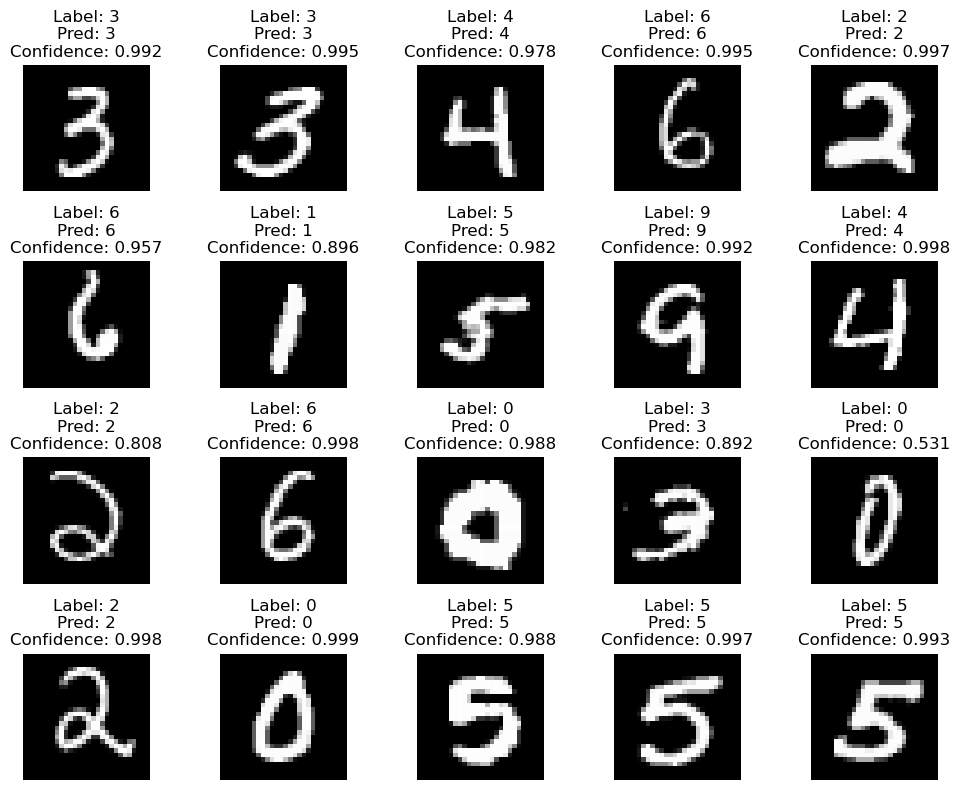

In [7]:
val_preds = network.forward(val_imgs[0:20])

index = np.argmax(val_preds, axis=1)
prob = np.max(val_preds, axis=1)

preds = index, prob

show_image_grid(np.squeeze(val_imgs, axis=1), val_labels_org, preds=preds, ids=range(20), cols=5)